# Q3

# HW2 Colab Starter — CIFAR-10 Classification (5 epochs, tiny subset)
*Compute Diary:* Run the next cell at the start and end of each session. Keep total GPU time ≤ **90 minutes**.

In [1]:
from datetime import datetime
import os, json
stamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
os.makedirs("diary", exist_ok=True)
with open("diary/compute_diary.txt", "a") as f:
    f.write(json.dumps({"event": "timestamp", "when": stamp}) + "\n")
print("⏱️ Compute diary timestamp:", stamp)

⏱️ Compute diary timestamp: 2025-11-11 20:45:16


## 0) Environment & GPU check

In [2]:
import torch, platform
print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.11.13
Torch: 2.4.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4090


## 1) Reproducibility (fixed seeds)

In [3]:
import random, numpy as np, torch
def set_seed(seed=0):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(0); print("✅ Seeds set to 0")

✅ Seeds set to 0


## 2) Data (CIFAR-10, fixed tiny subset)
- Use at most **20%** of the training set (change `SUBSET_FRACTION` if needed).
- Batch size ≤ 64.

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

SUBSET_FRACTION = 0.2   # set to 0.1 for even faster runs
BATCH_SIZE = 64

tfm_train = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor()])
tfm_test  = transforms.ToTensor()

root = "./data"
train_full = datasets.CIFAR10(root, train=True, download=True, transform=tfm_train)
test_set   = datasets.CIFAR10(root, train=False, download=True, transform=tfm_test)

rng = np.random.default_rng(0)
subset_size = int(len(train_full) * SUBSET_FRACTION)
subset_idx = rng.choice(len(train_full), size=subset_size, replace=False)
train_set = Subset(train_full, subset_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train subset:", len(train_set), " Test:", len(test_set))

Files already downloaded and verified
Files already downloaded and verified
Train subset: 10000  Test: 10000


## 3) Model (ResNet18) + 5-epoch training cap

In [5]:
import torch, torch.nn as nn
from torchvision.models import resnet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def make_model():
    m = resnet18(num_classes=10)
    return m.to(device)
EPOCHS = 5
LR = 1e-3

def train_one_config(optimizer_name="adam", use_cosine=False):
    model = make_model()
    if optimizer_name == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS) if use_cosine else None
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "test_acc": []}
    for epoch in range(1, EPOCHS+1):
        model.train(); running=0.0
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad(); out = model(x); loss = criterion(out,y); loss.backward(); opt.step()
            running += loss.item()*x.size(0)
        train_loss = running/len(train_loader.dataset)
        model.eval(); correct=0; total=0
        with torch.no_grad():
            for x,y in test_loader:
                x,y = x.to(device), y.to(device)
                pred = model(x).argmax(1); correct += (pred==y).sum().item(); total += y.size(0)
        acc = correct/total
        if sched: sched.step()
        history["train_loss"].append(train_loss); history["test_acc"].append(acc)
        print(f"Epoch {epoch:02d} | loss={train_loss:.4f} | acc={acc:.3f}")
    return history
print("✅ Training utilities ready.")

✅ Training utilities ready.


## 4) Run two short ablations (pick two knobs)

In [6]:
results = {}
print("\nRun Base: Adam + const"); results["base (adam+const)"] = train_one_config("adam", False)   # as the original config is not a strict controlled experiment, I added this line
print("\nRun A: Adam + cosine"); results["adam_cosine"] = train_one_config("adam", True)
print("\nRun B: SGD + const");  results["sgd_const"]  = train_one_config("sgd", False)


Run Base: Adam + const
Epoch 01 | loss=1.7319 | acc=0.334
Epoch 02 | loss=1.4341 | acc=0.440
Epoch 03 | loss=1.2722 | acc=0.471
Epoch 04 | loss=1.1649 | acc=0.538
Epoch 05 | loss=1.0664 | acc=0.526

Run A: Adam + cosine
Epoch 01 | loss=1.7573 | acc=0.369
Epoch 02 | loss=1.4225 | acc=0.470
Epoch 03 | loss=1.2327 | acc=0.536
Epoch 04 | loss=1.0158 | acc=0.568
Epoch 05 | loss=0.8188 | acc=0.620

Run B: SGD + const
Epoch 01 | loss=1.9653 | acc=0.383
Epoch 02 | loss=1.5981 | acc=0.417
Epoch 03 | loss=1.4330 | acc=0.457
Epoch 04 | loss=1.3028 | acc=0.478
Epoch 05 | loss=1.1912 | acc=0.428


## 5) Plot & tiny results table

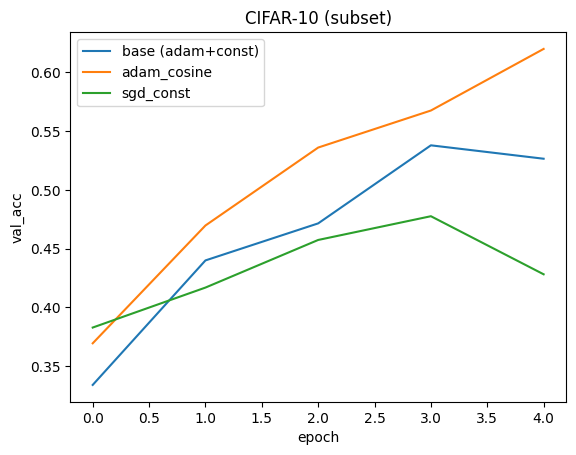

                   final_train_loss  final_val_acc
base (adam+const)          1.066395         0.5265
adam_cosine                0.818813         0.6199
sgd_const                  1.191152         0.4282


In [8]:
import matplotlib.pyplot as plt, pandas as pd
plt.figure()
for k,v in results.items():
    plt.plot(v["test_acc"], label=k)
plt.xlabel("epoch"); plt.ylabel("val_acc"); plt.title("CIFAR-10 (subset)"); plt.legend(); plt.show()
table = pd.DataFrame({k: [v["train_loss"][-1], v["test_acc"][-1]] for k,v in results.items()},
                     index=["final_train_loss","final_val_acc"]).T
print(table)

## 6 Reflection (3–5 sentences)
- Which knobs did you choose and why?

    I chose optimizer and Learning rate scheduler. I kept optimizer constant (adam) and tested different scheduler, and kept schedular constant (const) and tested optimizer. This is because optimizer is the key of training, and how LR changed with time will also significantly affect the train. 
- What changed in curves/table?

    The validation accuracy changed in different way for the three configurations. Adam cosine reached the highest validation accuracy and was mostly increasing. Adam const stuck at a plateau after epoch 3 and started decreasing. Sgd const performed the worst, as its val acc increased slow and started to drop more significantly after epoch 3.
- What would you try next with 10× more compute?

    I will try to use the whole data set to train the model. Plus, I will double the number of epochs. If it is allowed, I might try a more powerful model, such as ResNet 50.

## 7) **Project sketch** (≈150 words) — counts toward HW2 *Process* (5 pts)
- **Question:** What are you trying to investigate?

Learning Linux and Bash script system can be hard. We are nevigating a user-involved multi-agent system (Scheduler, command generator, validator, executor, etc.) to translate the natural language to bash script and automatically execute the commands by calling an MCP tool.
- **Data:** Which dataset(s) or data source?

We may use the *westenfelder/NL2SH-ALFA* dataset as a finetune set.
- **Metric(s):** What will you measure?

We will measure the final satisfactory rate evaluated by the user after inspecting the execution result and the run time during from receiveing the user's prompt to the execute of the command.
- **One ablation:** What single change will you compare vs baseline?

We may use prompt style as one ablation, for example, COT (baseline) vs non-COT (shorter and less structured, no thinking guide). 
- **Constraints:** Acknowledge the course caps (≤5 epochs, ≤90 min GPU total, fixed subset allowed).

We acknoledge the course caps, and our finetune set is relatively small (300 data). Also, in our design, the finetune training is optional. We have observed a lot of models have already acquired the ability to follow the language-to-script instruction.
- **Teammates (if any):** List names/NetIDs.

Cooperators: Terry Mu xm2204, Hengpu hp2723, Xukang Gong xg2489

> This is a draft. You can change it in the Dec 1 proposal.